<a href="https://colab.research.google.com/github/tether007/DIP/blob/main/MPP_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`Thermal Image
->
Simulated Damage
->
Mask Detection
->
Restored Image
->
PSNR / similarity score`

#1 . Initial data preprocessing
# Its basically sensor image -> detect corrupted part -> Mask gen -> prepare a Tensor rep. -> Feed it directly to DIP

In [1]:
import torch

# Device agnostic code

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
device

'cuda'

# 2 . Imports and necessary packages

In [10]:
import torch
from torch import nn
#vision libs
import torchvision

from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

#import visuaal stuff
import matplotlib.pyplot as plt
import cv2 as cv



In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepnewbie/flir-thermal-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 15.3G/15.3G [14:40<00:00, 18.6MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1


In [13]:
path

'/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1'

Checking path:
/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train/thermal_16_bit
Exists: True
Total TIFF files: 8862
Loading: /root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1/FLIR_ADAS_1_3/train/thermal_16_bit/FLIR_01656.tiff
Shape: (512, 640)
Datatype: uint16


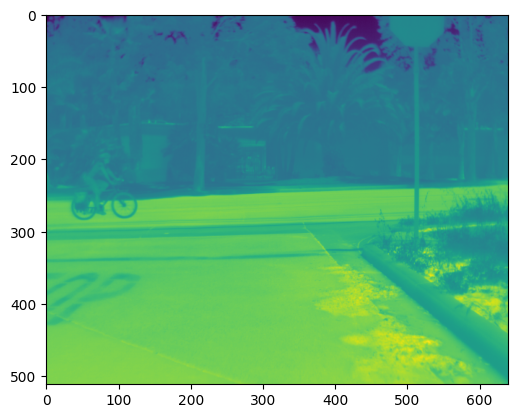

In [218]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_root = "/root/.cache/kagglehub/datasets/deepnewbie/flir-thermal-images-dataset/versions/1"

thermal_16_bit_dir = os.path.join(
    dataset_root,
    "FLIR_ADAS_1_3",
    "train",
    "thermal_16_bit"
)

print("Checking path:")
print(thermal_16_bit_dir)

print("Exists:", os.path.exists(thermal_16_bit_dir))

# List TIFF files
image_files = [
    f for f in os.listdir(thermal_16_bit_dir)
    if f.endswith(".tiff")
]

print("Total TIFF files:", len(image_files))

# Load first image
sample_image_path = os.path.join(
    thermal_16_bit_dir,
    image_files[0]
)

print("Loading:", sample_image_path)

# Read the image first
image = cv2.imread(sample_image_path, cv2.IMREAD_UNCHANGED)
plt.imshow(image)
print("Shape:", image.shape)
print("Datatype:", image.dtype)



In [219]:
image  = cv2.imread(sample_image_path, cv2.IMREAD_UNCHANGED)

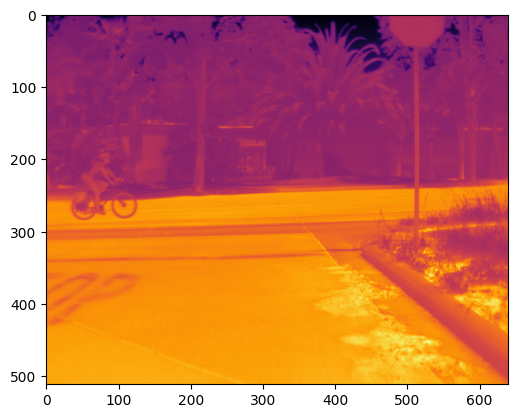

In [220]:
plt.imshow(image,cmap="inferno")

In [221]:
normalized = cv2.normalize(
    image,
    None,
    0,
    1,
    cv2.NORM_MINMAX,
    dtype=cv2.CV_32F
)

#3 . Adding Gausian noise to simulate for NOW

In [222]:
import numpy as np

noise = np.random.normal(0, 0.02, normalized.shape)

corrupted = normalized + noise

corrupted = np.clip(corrupted, 0, 1)

corrupted = corrupted.astype(np.float32)

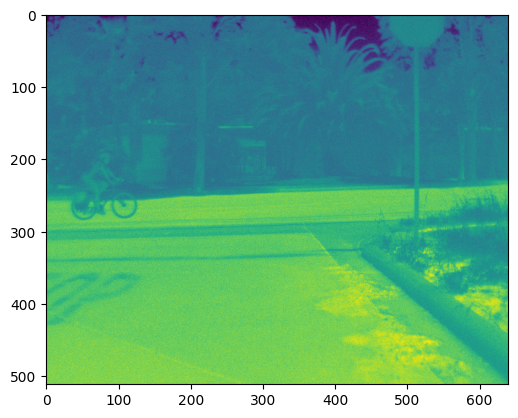

In [223]:
plt.imshow(corrupted)

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

<Figure size 1000x700 with 0 Axes>

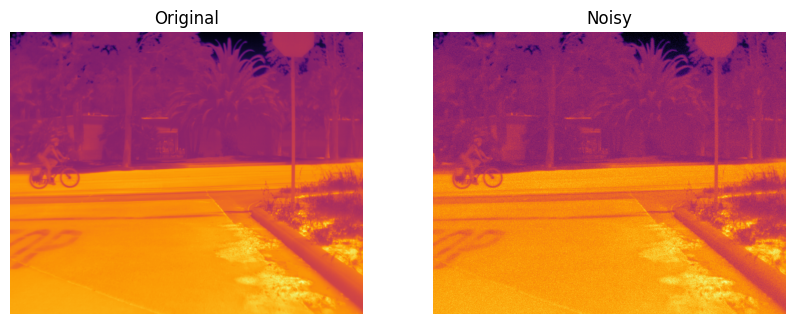

In [224]:
plt.figure(figsize=(10,7))
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Original Image
axes[0].imshow(normalized, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# Noisy Image
axes[1].imshow(corrupted, cmap='inferno')
axes[1].set_title("Noisy")
axes[1].axis('off')


## 3.1 Adding missing(to simulate inpainting )

In [314]:
corrupted2 = corrupted.copy()

corrupted2[150:300, 100:200] = 0


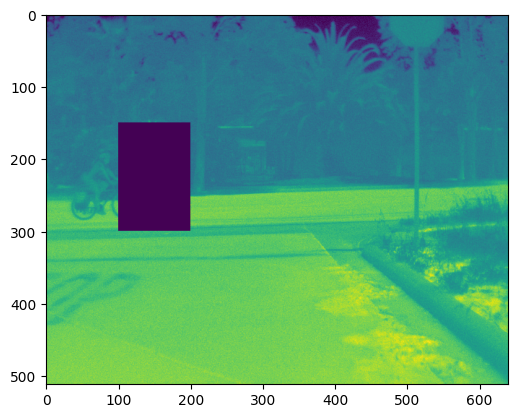

In [316]:
plt.imshow(corrupted2)

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

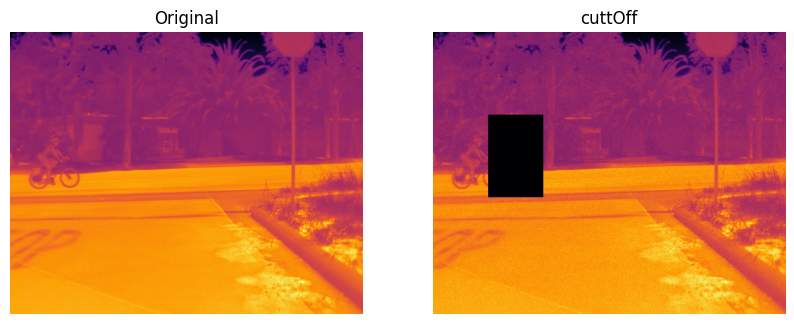

In [317]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Original Image
axes[0].imshow(normalized, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# missing region Image
axes[1].imshow(corrupted2, cmap='inferno')
axes[1].set_title("cuttOff")
axes[1].axis('off')

#4 . Creating a simple Mask for the given image
*. As simple as valid pixel -> 1, else 0





In [318]:
mask = (corrupted2 > 0).astype(np.float32)

In [319]:
mask

array([[1., 1., 0., ..., 1., 1., 1.],
       [1., 0., 0., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

# 5 . Img to Tensor (Highly crucial since it was numpy till now , but fro pytorch we need it in tensor)

* now we are worried about the "noiseful image"

## 5.1 . corr_Img -> tensor

In [320]:
image_tensor = torch.tensor(corrupted).float()

In [321]:
image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)# adding an extra dimension for W and H

In [322]:
print(image_tensor.min().item())
print(image_tensor.max().item())

0.0
1.0


##5.11 corr2_img->tensor

In [323]:
corr2_tensor = torch.tensor(corrupted2).float()
corr2_tensor = corr2_tensor.unsqueeze(0).unsqueeze(0)

In [324]:
print(corr2_tensor.min().item())
print(corr2_tensor.max().item())

0.0
1.0


## 5.2 . mask -> tensor

In [325]:
mask_tensor = torch.tensor(mask).float()

## 5.3 . org_img -> tensor

In [326]:
org_tensor = torch.tensor(image).float()

In [327]:
org_tensor = org_tensor.unsqueeze(0).unsqueeze(0)

##6 . Visualizing all the tensors
* Tensor to Numpy and then viz

<Figure size 1000x700 with 0 Axes>

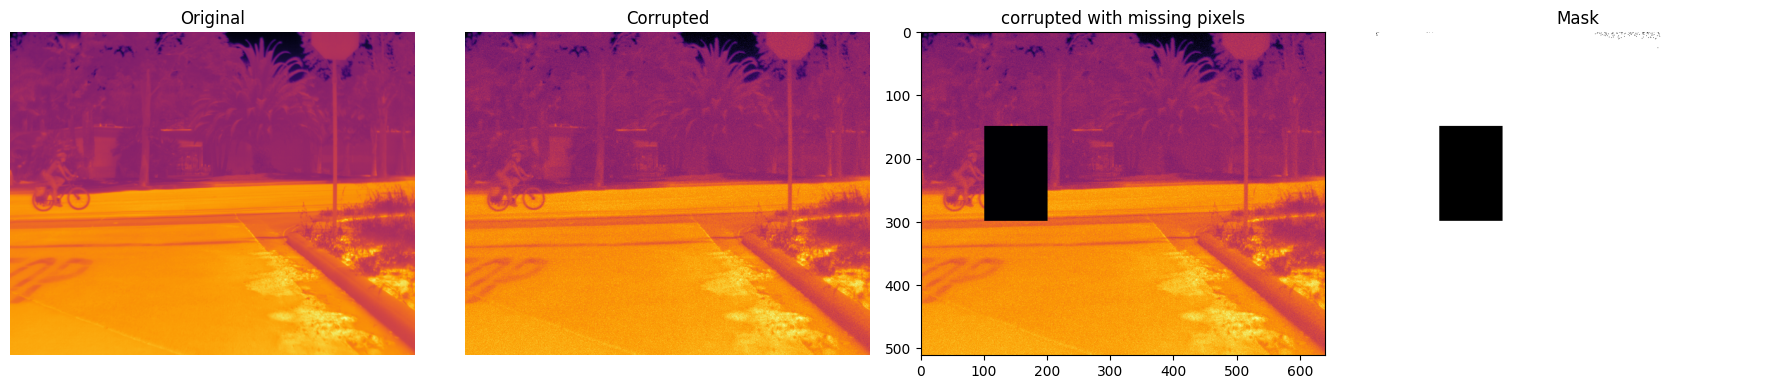

In [328]:
original_np = org_tensor.squeeze().cpu().numpy()
corrupted_np = image_tensor.squeeze().cpu().numpy()
corrupted2_np = corr2_tensor.squeeze().cpu().numpy()
mask_np = mask_tensor.squeeze().cpu().numpy()

plt.figure(figsize=(10,7))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original
axes[0].imshow(original_np, cmap='inferno')
axes[0].set_title("Original")
axes[0].axis('off')

# Corrupted wiht noise
axes[1].imshow(corrupted_np, cmap='inferno')
axes[1].set_title("Corrupted")
axes[1].axis('off')

#corrupted with degradation(pixel missing)
axes[2].imshow(corrupted2, cmap="inferno")
axes[2].set_title("corrupted with missing pixels")
axes[1].axis('off')

# Mask
axes[3].imshow(mask_np, cmap='gray')
axes[3].set_title("Mask")
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 7 . To be Practical in the given sit lets start with a Encoder-Decoder CNN

In [329]:
import torch
import torch.nn as nn

class SimpleDIP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 1, 3, padding=1)

        )

    def forward(self, x):
        return self.net(x)

In [330]:
modelV1 = SimpleDIP()

In [331]:
modelV1.state_dict

<bound method Module.state_dict of SimpleDIP(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)>

## 7.1 start here with our mini-scaled implementation

### DAC

In [332]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [333]:
modelV1.to(device)

SimpleDIP(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

### Move the tensors to device too

In [334]:
original_tensor = org_tensor.to(device)

corrupted_tensor = corr2_tensor.to(device)

mask_tensor = mask_tensor.to(device)

### Random noice `z`

In [335]:
z = torch.randn_like(corrupted_tensor).to(device)
print(z.min(), z.max())
print(corrupted_tensor.min().item())
print(corrupted_tensor.max().item())

tensor(-4.3706, device='cuda:0') tensor(4.7245, device='cuda:0')
0.0
1.0


### Optimizer(adam) for now

In [336]:
optimizer = torch.optim.Adam(
    modelV1.parameters(),
    lr=0.001
)

## 8 . Training Loop

In [344]:
num_iterations = 3000

for i in range(num_iterations):

    optimizer.zero_grad()

    # Forward pass
    output = modelV1(z)

    # calculate the loss
    loss = (
        ((output - corrupted_tensor)) ** 2
    ).mean()
    # Optim zero grad
    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Print progress
    if i % 200 == 0:
        print(f"Iteration {i} | Loss: {loss.item()} | {(output.min().item(), output.max().item())}")

Iteration 0 | Loss: 0.025454435497522354 | (-0.27264609932899475, 1.2500298023223877)
Iteration 200 | Loss: 0.025165939703583717 | (-0.3471387028694153, 1.1702417135238647)
Iteration 400 | Loss: 0.02484232746064663 | (-0.3425217270851135, 1.177237868309021)
Iteration 600 | Loss: 0.023695437237620354 | (-0.3184502422809601, 1.2098535299301147)
Iteration 800 | Loss: 0.023321110755205154 | (-0.31000006198883057, 1.262222409248352)
Iteration 1000 | Loss: 0.023498384281992912 | (-0.2912384271621704, 1.2783703804016113)
Iteration 1200 | Loss: 0.023327358067035675 | (-0.34012141823768616, 1.1973114013671875)
Iteration 1400 | Loss: 0.02318253181874752 | (-0.28926870226860046, 1.259871006011963)
Iteration 1600 | Loss: 0.022816209122538567 | (-0.3472958505153656, 1.208846926689148)
Iteration 1800 | Loss: 0.02285361848771572 | (-0.29529914259910583, 1.2612178325653076)
Iteration 2000 | Loss: 0.02229984477162361 | (-0.342536985874176, 1.2124855518341064)
Iteration 2200 | Loss: 0.02194284461438656 

### 9 . Viz after

In [345]:
output_image = output.detach().cpu().squeeze().numpy()

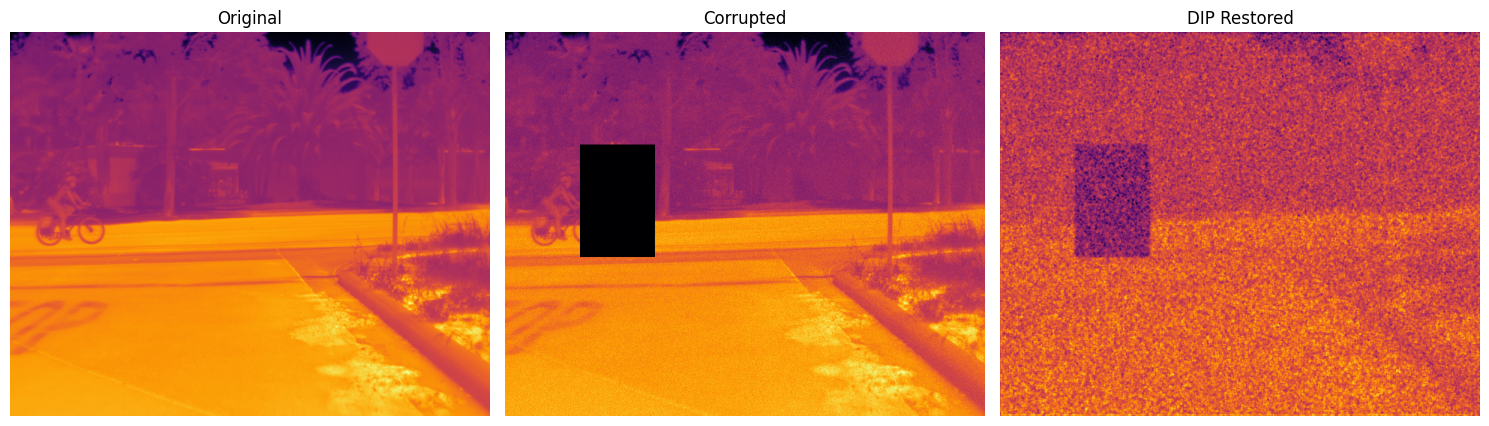

In [346]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Original
axes[0].imshow(
    org_tensor.cpu().squeeze(),
    cmap='inferno'
)
axes[0].set_title("Original")
axes[0].axis('off')

# Corrupted
axes[1].imshow(
    corr2_tensor.cpu().squeeze(),
    cmap='inferno'
)
axes[1].set_title("Corrupted")
axes[1].axis('off')

# Restored
axes[2].imshow(
    output_image,
    cmap='inferno'
)
axes[2].set_title("DIP Restored")
axes[2].axis('off')

plt.tight_layout()
plt.show()